In [1]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
print(df.isna().sum())
print("Shape:", df.shape) 
print("Duplicates:", df.duplicated().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Shape: (1025, 14)
Duplicates: 723


In [5]:
df = df.drop_duplicates().reset_index(drop=True)
print("New shape:", df.shape)

New shape: (302, 14)


In [6]:
print(df['target'].value_counts())
print(df["target"].value_counts(normalize=True) * 100)

target
1    164
0    138
Name: count, dtype: int64
target
1    54.304636
0    45.695364
Name: proportion, dtype: float64


In [7]:
print(df.describe().T)

          count        mean        std    min     25%    50%     75%    max
age       302.0   54.420530   9.047970   29.0   48.00   55.5   61.00   77.0
sex       302.0    0.682119   0.466426    0.0    0.00    1.0    1.00    1.0
cp        302.0    0.963576   1.032044    0.0    0.00    1.0    2.00    3.0
trestbps  302.0  131.602649  17.563394   94.0  120.00  130.0  140.00  200.0
chol      302.0  246.500000  51.753489  126.0  211.00  240.5  274.75  564.0
fbs       302.0    0.149007   0.356686    0.0    0.00    0.0    0.00    1.0
restecg   302.0    0.526490   0.526027    0.0    0.00    1.0    1.00    2.0
thalach   302.0  149.569536  22.903527   71.0  133.25  152.5  166.00  202.0
exang     302.0    0.327815   0.470196    0.0    0.00    0.0    1.00    1.0
oldpeak   302.0    1.043046   1.161452    0.0    0.00    0.8    1.60    6.2
slope     302.0    1.397351   0.616274    0.0    1.00    1.0    2.00    2.0
ca        302.0    0.718543   1.006748    0.0    0.00    0.0    1.00    4.0
thal      30

Total 14 columns
├── target (target column)
├── Continuous numeric (5): age, trestbps, chol, thalach, oldpeak
│   └── Scaling (StandardScaler)
└── Categorical (8): sex, cp, fbs, restecg, exang, slope, ca, thal
    └── Encoding (One-Hot), not scaling

Original shape: (1025, 14), no missing values.
Found 723 duplicate rows → dropped duplicates → final shape: (302, 14).
Target balance: 54.3% disease (1), 45.7% no disease (0) → reasonably balanced, accuracy is a valid metric here (not misleading like a 95:5 split would be).
Feature types identified:
Continuous numeric (need scaling): age, trestbps, chol, thalach, oldpeak
Ordinal (numeric-like order, scale as numeric): ca
Nominal categorical (need One-Hot Encoding): sex, cp, fbs, restecg, exang, slope, thal

# Univariate Analysis

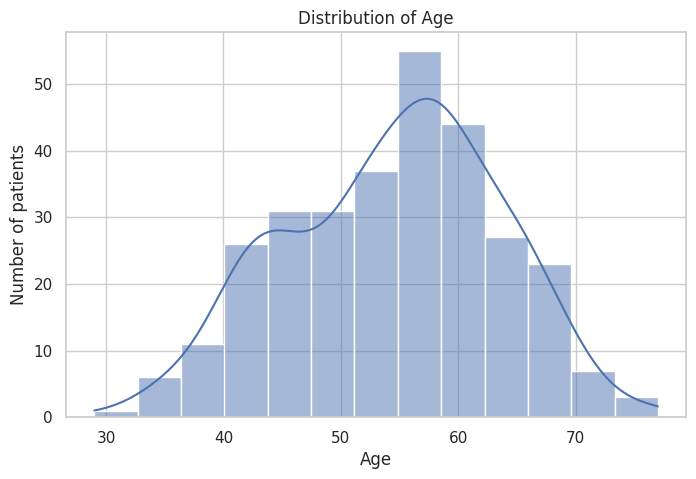

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,5))
sns.histplot(df['age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel("Number of patients")
plt.show()

Age distribution (univariate):

* Roughly bell-shaped but left-skewed with a slight bimodal shape — one small bump around 44–48, one larger peak around 55–58.
* Peak patient age: ~55–58 years.
* Not a perfectly normal distribution, so StandardScaler will be a slight approximation but acceptable.

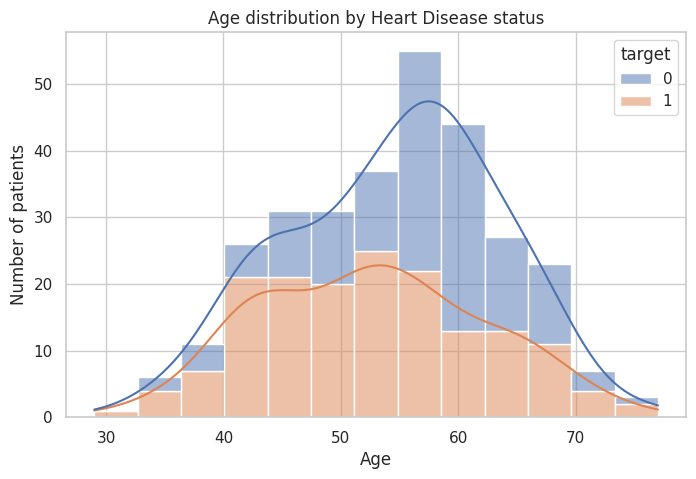

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='age', hue='target', kde=True, multiple='stack')
plt.title("Age distribution by Heart Disease status")
plt.xlabel("Age")
plt.ylabel("Number of patients")
plt.show()

Age vs Target (bivariate):

* Counter-intuitive pattern: younger patients (40–52) show a higher proportion of disease (target=1), while older patients (55–70) show a higher proportion of no-disease (target=0).
* Confirmed target=1 = disease present, target=0 = no disease (no label reversal).
* Likely explanation: selection bias — younger patients in this clinical dataset may have come in specifically due to symptoms, while older patients may include more routine-checkup (healthy) cases. Could also be partly small-sample noise (n=302).
* Conclusion: age alone is a weak/inconsistent predictor in this dataset.

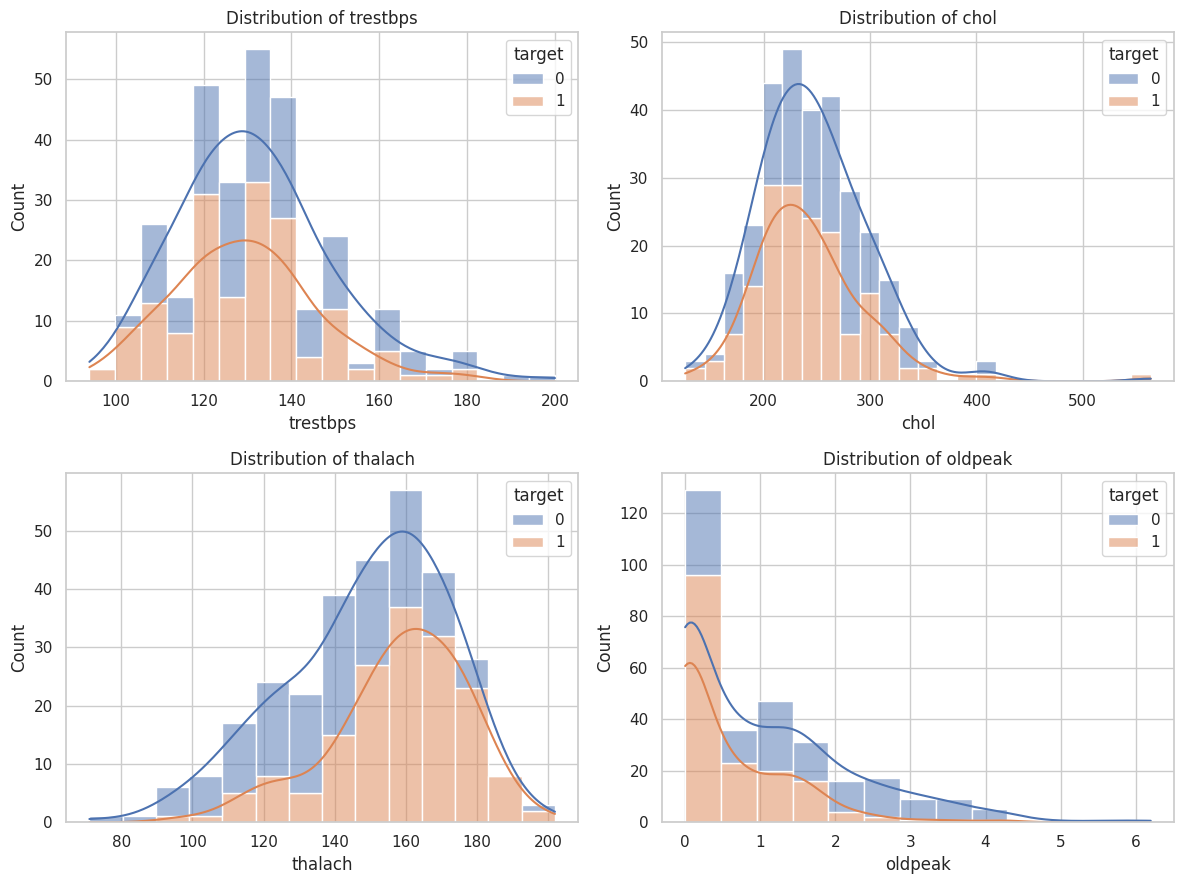

In [10]:
num_cols = ["trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, col in zip(axes, num_cols):
   sns.histplot(data=df, x=col, hue="target", kde=True, multiple="stack", ax=ax)
   ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

1. trestbps (resting blood pressure) vs Target:

* Large overlap between disease/no-disease distributions.
* Weak standalone predictor.

2. chol (cholesterol) vs Target:

* Distributions nearly identical in shape between the two classes.
* Weakest standalone predictor among the numeric features, despite cholesterol being a classically expected risk factor — may only add value in combination with other features.
* Contains a few visible outliers in the 400–560+ range.

3. thalach (max heart rate) vs Target:

* Clear separation: patients with disease (target=1) skew toward higher max heart rate (~150–180), while healthy patients cluster more in the 120–150 range.
* Strong standalone predictor.

4. oldpeak (ST depression) vs Target:

* Clear separation: oldpeak ≈ 0 is associated with more healthy patients; as oldpeak increases, proportion of disease patients increases.
* Strong standalone predictor, consistent with its clinical role as a stress-test marker.

5. Relative feature strength (visual, to be confirmed numerically via correlation):

chol < trestbps < age  <  thalach ≈ oldpeak
(weak)                    (strong)

6. Key conceptual takeaway — feature redundancy:

* Physiologically, age and thalach are expected to be negatively related (max heart rate declines with age, per the rough rule max HR ≈ 220 − age).
* If two features are correlated, they carry overlapping information — including both in a distance-based model like KNN can cause implicit "double-counting" of the same underlying signal.

7. Next step: quantify this relationship using a correlation heatmap (df.corr() + sns.heatmap) to numerically verify which features are redundant and which are most associated with target.

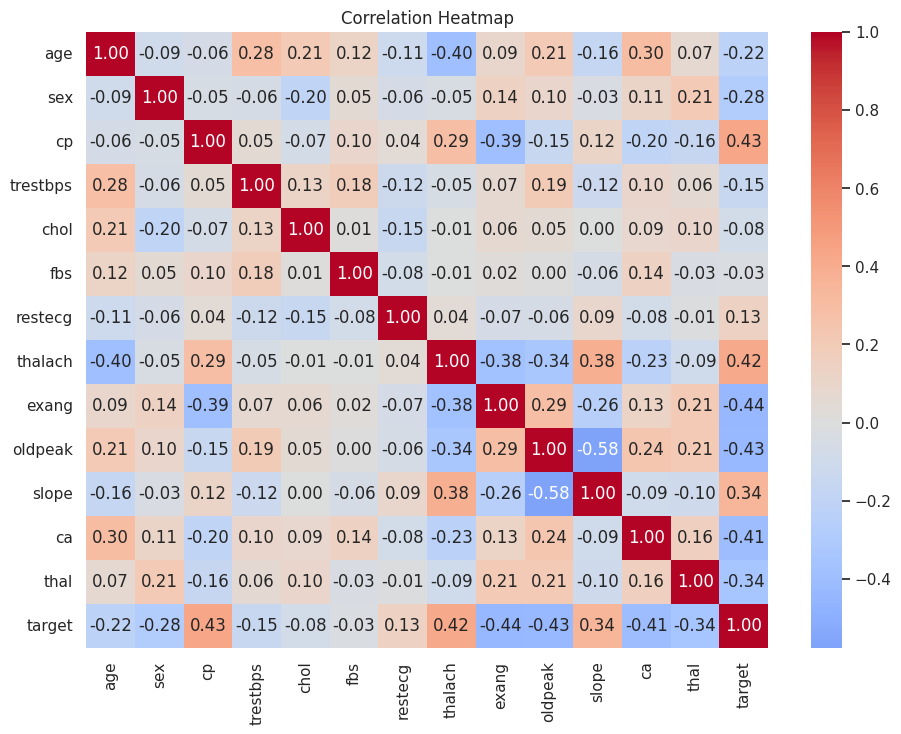

In [11]:
plt.figure(figsize=(11,8))

corr = df.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

📓 Notes: Correlation Heatmap Analysis

1. Method: df.corr() computes Pearson correlation coefficient between every pair of numeric columns, values range from −1 to +1. Magnitude = strength of relationship, sign = direction (+ve = move together, −ve = move oppositely). Diagonal is always 1.00 (self-correlation) and carries no information.

2. Correlation with target (sorted by strength):

* Strong (|r| > 0.4):   cp (+0.43), exang (−0.44), thalach (+0.42),
                       oldpeak (−0.43), ca (−0.41)
* Medium (0.3–0.4):     slope (+0.34), thal (−0.34)
* Weak (0.1–0.3):       sex (−0.28), age (−0.22), restecg (+0.13),
                       trestbps (−0.15)
* Negligible (<0.1):    fbs (−0.03), chol (−0.08)

3. Key finding: chol, despite being a classically known risk factor, shows almost no linear correlation with target (−0.08) in this dataset, consistent with the weak signal seen in its univariate/bivariate distribution plot. Likely to contribute little standalone predictive value; may need interaction with other features or may simply be a weak feature in this particular sample.

4. Confirmed feature redundancy (multicollinearity candidates):

* age and thalach: r = −0.40 → moderately strong negative relationship, consistent with the known physiological pattern that max heart rate declines with age (approx. 220 − age).
* oldpeak and slope: r = −0.58 → the strongest off-diagonal correlation in the dataset; these two features are substantially redundant.

5. Implication for modeling:

* Redundant/correlated feature pairs contribute overlapping information to distance-based calculations in KNN, effectively over-weighting that shared signal.
* Candidates for chol and weak features: consider dropping or de-prioritizing via feature selection (SelectKBest/mutual information) in Stage 7.
* Candidates for age/thalach and oldpeak/slope: candidates for PCA-based dimensionality reduction, or careful feature selection to avoid double-counting correlated signal.
* Note: correlation only captures linear relationships — a feature with low linear correlation to target could still be informative in combination with others or via non-linear interactions; mutual information

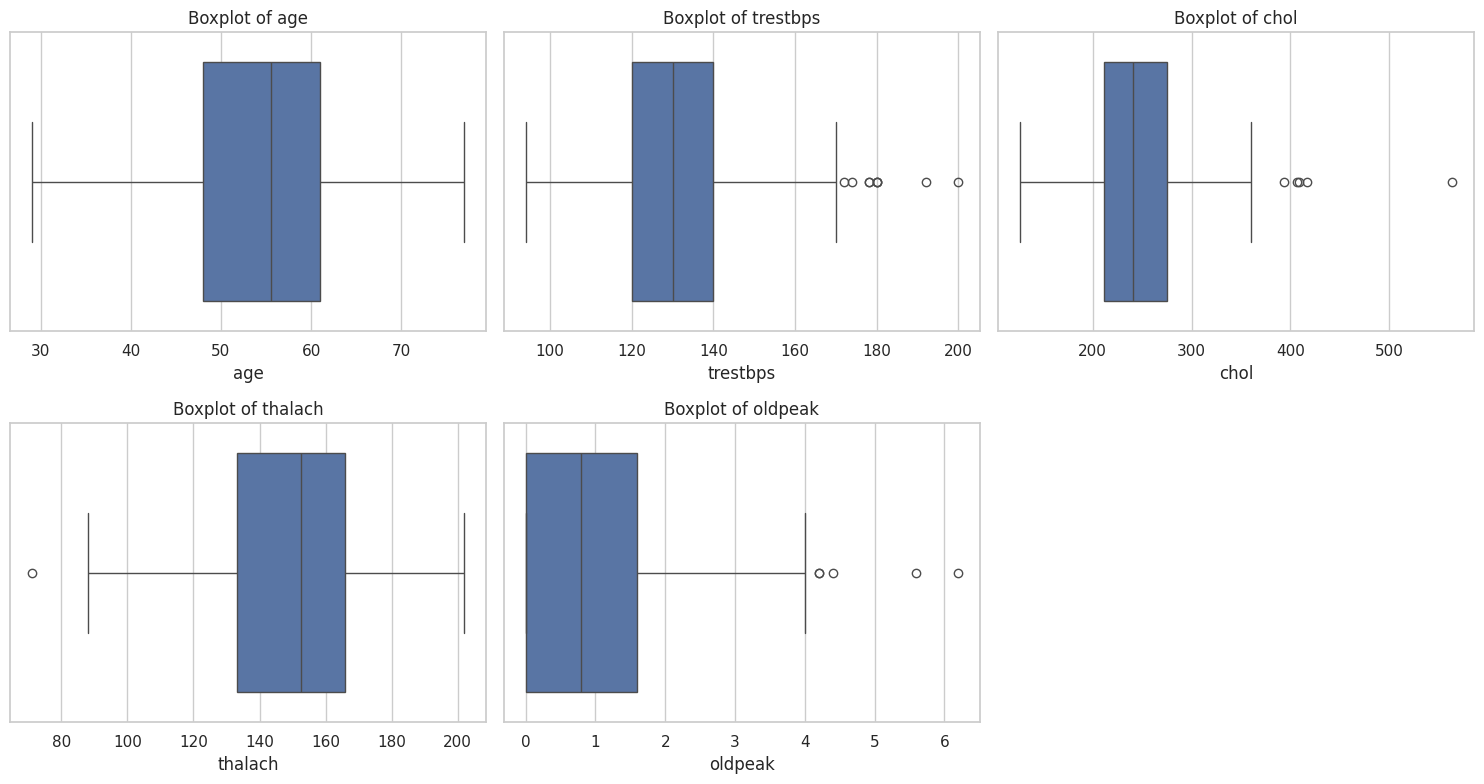

In [12]:
nums_col = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, nums_col):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Boxplot of {col}")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

📓 Notes: Box Plot & Outlier Analysis

Method: Box plot shows 5-number summary (min-within-range, Q1, median, Q3, max-within-range) plus outliers as individual points, using the standard IQR rule: outlier if value < Q1 − 1.5×IQR or value > Q3 + 1.5×IQR.

Findings per column:

Column	Outliers	Direction	Severity
age	None	—	Clean distribution
trestbps	~5 points	High side only (~170–200)	Moderate
chol	~5 points	High side only	One extreme outlier at ~560, well separated from the rest
thalach	1 point	Low side only (~71)	Mild
oldpeak	~4 points	High side only (~4.2–6.2)	Moderate

Pattern observed: Most outliers occur on the high end of the distribution (consistent with the right-skew seen in the earlier histograms), except thalach, where the single outlier is on the low end.

Decision on outlier handling:

All flagged values are physiologically plausible (e.g., chol=560 is extreme but medically possible, not a data-entry error), so outliers were not removed — they may carry real signal (extreme values could correlate with higher disease risk).
Mitigation strategy instead of removal:
Consider RobustScaler (uses median/IQR) instead of StandardScaler (uses mean/std) during the scaling stage, since it is less sensitive to outliers.
Avoid very small K in KNN (e.g., K=1), since a single extreme-valued neighbor could otherwise disproportionately influence predictions.

General rule applied: Only remove outliers if they are physiologically/logically impossible (e.g., cholesterol = 0). If plausible but extreme, retain the data and instead adjust preprocessing (robust scaling) and model hyperparameters (larger K) to reduce their influence.

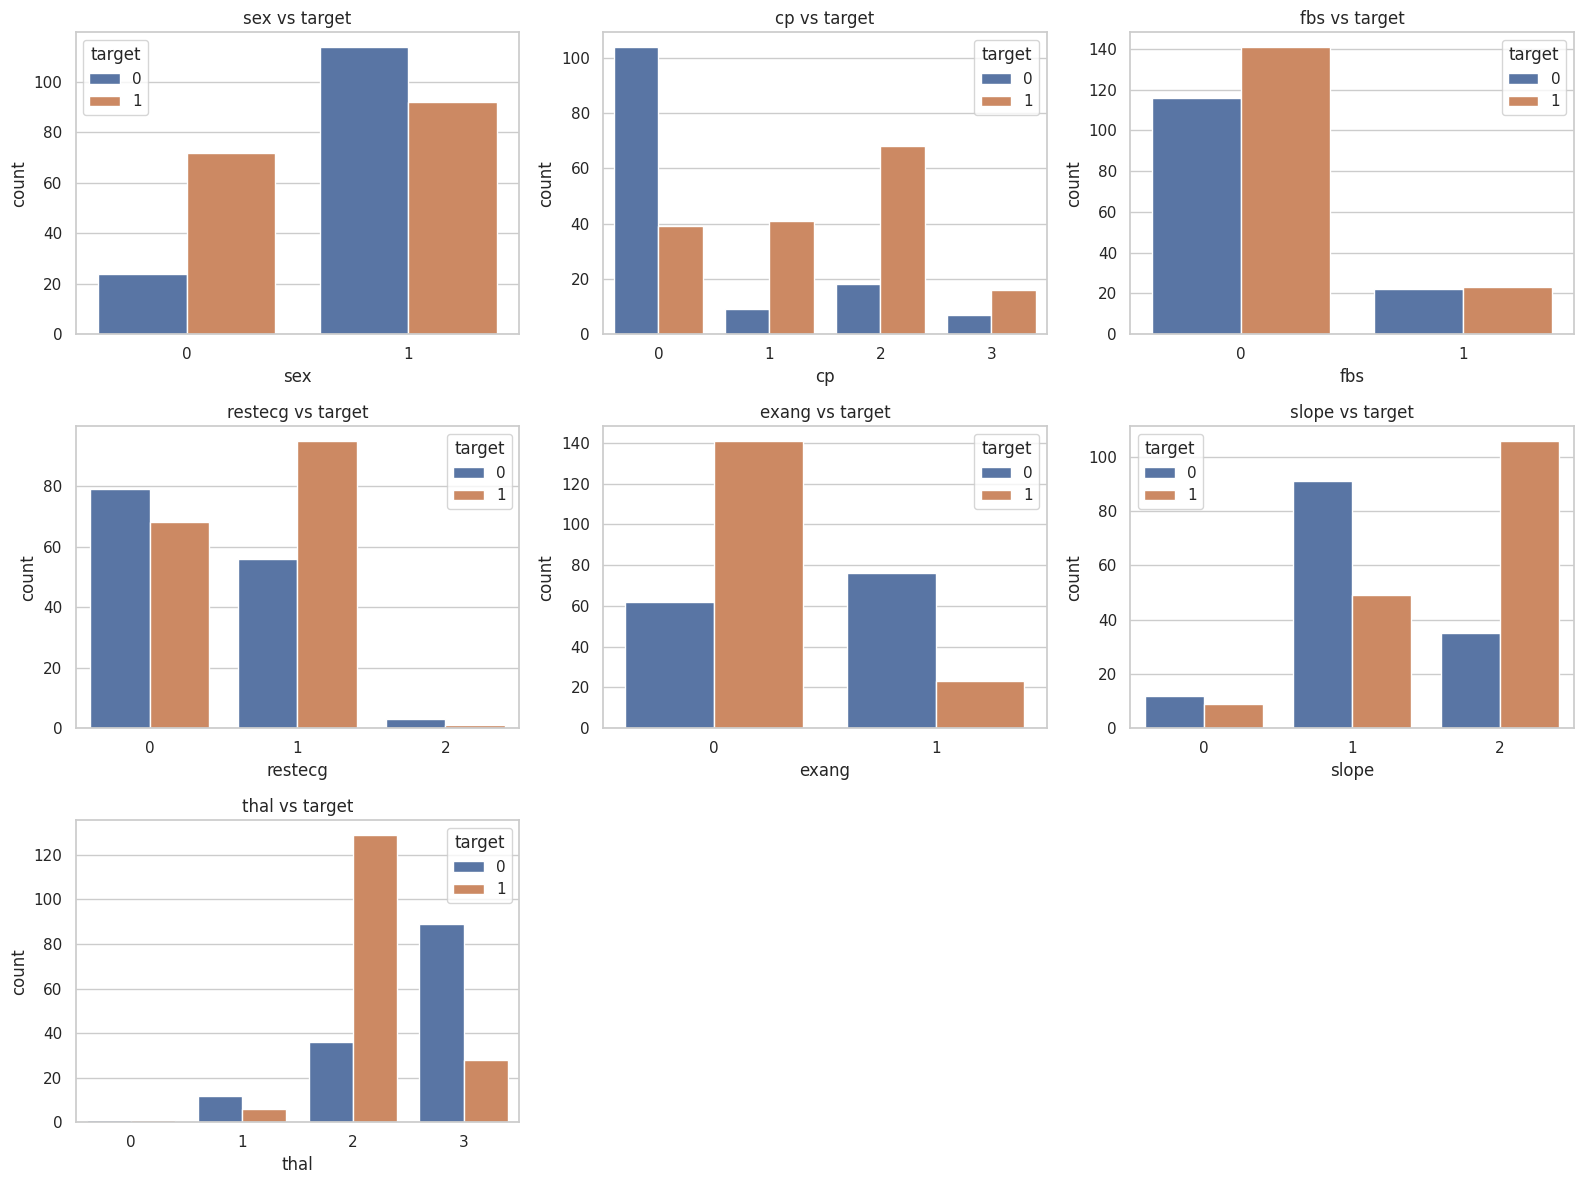

In [13]:
cat_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for ax, col in zip(axes, cat_features):
    sns.countplot(data=df, x=col, hue="target", ax=ax)
    ax.set_title(f"{col} vs target")

axes[-1].axis("off")
axes[-2].axis("off")

plt.tight_layout()
plt.show()

## 📓 Notes: Categorical Features vs Target Analysis

**Method:** Count plots with `hue="target"` split each categorical feature's values into
disease (1) vs no-disease (0) counts, allowing visual comparison of class proportions
within each category.

### Findings per feature

| Feature | Pattern | Strength |
|---|---|---|
| `sex` | `sex=0` group shows much higher disease proportion (~75%) vs `sex=1` (~45%, near-balanced) | Moderate |
| `cp` (chest pain type) | `cp=0` is mostly no-disease (73%); `cp=1,2,3` are all mostly disease (70–82%) | **Strong** — cleanest categorical signal |
| `fbs` | Disease proportion nearly identical across both groups (~55% vs ~51%) | **Negligible** — candidate for removal in feature selection |
| `restecg` | `restecg=1` skews toward disease (63%); `restecg=2` has too few samples (n=4) to be reliable | Weak–moderate |
| `exang` | Counter-intuitive: `exang=0` (no exercise-induced pain) is 69% disease, `exang=1` (pain present) is only 22% disease — opposite of the expected clinical direction | **Strong statistically**, despite unexpected direction. Retained for modeling since KNN only needs separation between groups, not causal direction. Consistent with the similarly counter-intuitive `age` pattern seen earlier — likely a dataset-specific sampling characteristic. |
| `slope` | `slope=1` mostly no-disease (65%), `slope=2` mostly disease (76%); `slope=0` has too few samples (n=19) | Moderate–strong |
| `thal` | `thal=2` mostly disease (78%), `thal=3` mostly no-disease (77%); `thal=0` has almost no samples (n=1) | Strong |

### Consolidated feature strength assessment
*(combining numeric + categorical EDA so far)*

- **Strong predictors:** `cp`, `exang`, `thalach`, `oldpeak`, `ca`, `slope`, `thal`
- **Weak/negligible predictors:** `chol`, `fbs`, `trestbps`, `restecg`

These findings will be quantitatively validated in the Feature Selection stage
(mutual information / `SelectKBest`), which can also capture non-linear
relationships that simple correlation and visual inspection might miss.

### Caveat

Categories with very small sample sizes (`restecg=2`, `slope=0`, `thal=0`, `thal=1`)
should be interpreted cautiously — their apparent patterns may not be statistically
reliable given limited data.

# Feature Engineering

In [14]:
# Feature 1: Heart Rate Reserve

df["hr_reserve"] = (220 - df["age"]) - df["thalach"]

# Feature 2: Age Groups

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 40, 55, 70, 120],
    labels=["<40", "40-55", "55-70", "70+"]
)

print(df[["age", "hr_reserve", "age_group"]].head(10))

   age  hr_reserve age_group
0   52           0     40-55
1   53          12     40-55
2   70          25     55-70
3   61          -2     55-70
4   62          52     55-70
5   58          40     55-70
6   58          22     55-70
7   55          20     40-55
8   46          30     40-55
9   54          50     40-55


# Step: Train/Test Split

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="target")
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size= 0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("\nTrain target balance:")
print(y_train.value_counts(normalize=True))
print("\nTest target balance:")
print(y_test.value_counts(normalize=True))

Train shape: (241, 15)
Test shape : (61, 15)

Train target balance:
target
1    0.543568
0    0.456432
Name: proportion, dtype: float64

Test target balance:
target
1    0.540984
0    0.459016
Name: proportion, dtype: float64


## 📓 Notes: Feature Engineering & Train/Test Split

### Feature Engineering

Two new features created (domain-knowledge-driven, computed via fixed formulas
— no data-dependent fitting, so safe to do before the train/test split):

1. **`hr_reserve`** = `(220 − age) − thalach`
   - Combines `age` and `thalach` (which showed a −0.40 correlation, i.e.
     redundant information) into a single derived signal.
   - Positive value → actual max heart rate achieved was *below* the
     age-expected maximum (possible indicator of reduced cardiac fitness).
   - Negative value → actual heart rate *exceeded* the age-expected maximum.
   - Verified on sample rows: values ranged from −2 to +52, confirming the
     formula behaves correctly in both directions.

2. **`age_group`** = binned version of `age` into 4 buckets:
   `<40`, `40-55`, `55-70`, `70+` (via `pd.cut`)
   - Rationale: earlier EDA showed `age`'s relationship with `target` was
     non-monotonic/counter-intuitive; grouping may surface clearer patterns
     than the raw continuous value.

### Train/Test Split

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
```

- **Split ratio:** 80/20 → Train: 241 rows, Test: 61 rows (15 columns each,
  13 original features + 2 engineered features).
- **`stratify=y`** used to preserve the target class ratio across splits.
  Verified via `value_counts(normalize=True)`:

| Split | Disease (1) | No Disease (0) |
|---|---|---|
| Full dataset | 54.30% | 45.70% |
| Train | 54.36% | 45.64% |
| Test | 54.10% | 45.90% |

  Ratios match closely across all three (within ~0.3%, attributable to
  rounding with a small dataset), confirming stratification worked as
  intended. Without `stratify`, a random split on this small dataset
  (n=302) could plausibly have produced an imbalanced train/test split
  by chance.

- **`random_state=42`** fixes the random split for reproducibility — running
  the same code again will always produce the identical split.

### Why split before feature selection / scaling / encoding

Any step that "learns" from the data (scaling parameters, encoding categories,
feature selection scores, PCA components) must be fit **only on the training
set** and then applied to the test set — never fit on the full dataset before
splitting. Fitting such steps before the split leaks test-set information
into decisions the model shouldn't have access to at training time, and would
subsequently yield overly optimistic evaluation metrics on the test set.
Feature engineering (fixed-formula derived columns) is an exception since it
introduces no data-dependent learning, so it was safely done before the split.

# Step: Encoding + Scaling (ColumnTransformer)

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_features = ["age", "trestbps", "chol", "thalach", "oldpeak", "hr_reserve", "ca"]
cat_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal", "age_group"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

X_train_transformed = preprocess.fit_transform(X_train)
X_test_transformed = preprocess.transform(X_test)

print("Train transformed shape:", X_train_transformed.shape)
print("Test transformed shape :", X_test_transformed.shape)

Train transformed shape: (241, 31)
Test transformed shape : (61, 31)


## 📓 Notes: Encoding + Scaling (ColumnTransformer)

### Approach

Used `sklearn.compose.ColumnTransformer` to apply different preprocessing to
different column groups in a single fitted object:

- **Numeric columns** (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`,
  `hr_reserve`, `ca`) → `StandardScaler()`
  - `ca` is ordinal (values already numeric, 0–4, with meaningful order),
    so StandardScaler alone is sufficient — it rescales values while
    preserving their relative order. `OrdinalEncoder` would only have
    been needed if the ordinal data were originally text/string labels.
- **Categorical columns** (`sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`,
  `thal`, `age_group`) → `OneHotEncoder(handle_unknown="ignore")`
  - `handle_unknown="ignore"` prevents errors if the test set contains a
    category value never seen in training (encodes it as all-zeros instead
    of raising an exception).

### Fit/transform discipline (avoiding leakage)

```python
X_train_transformed = preprocess.fit_transform(X_train)   # learns + applies
X_test_transformed  = preprocess.transform(X_test)          # applies only
```

`fit_transform` on training data learns scaling parameters (mean/std) and
encoding categories from the training set only. `transform` (no fit) on the
test set applies those same learned parameters — the test set contributes
nothing to how scaling/encoding is defined, preventing data leakage.

### Shape verification

| | Rows | Columns |
|---|---|---|
| Before transform | 241 / 61 (train/test) | 15 |
| After transform | 241 / 61 (train/test) | 31 |

Column expansion accounted for: 7 numeric columns stay as 7, while 8
categorical columns expand via one-hot encoding into 24 binary columns
(sex: 2, cp: 4, fbs: 2, restecg: 3, exang: 2, slope: 3, thal: 4,
age_group: 4 → sum = 24). Total: 7 + 24 = 31, matching the observed shape.
Train and test produced identical column counts, confirming consistent
encoding across both sets.

# Step: Feature Selection (Mutual Information)

In [17]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Column names after transformation
feature_names = preprocess.get_feature_names_out()

# Mutual Information
mi_scores = mutual_info_classif(X_train_transformed, y_train, random_state=42)

mi_series = pd.Series(mi_scores, index=feature_names).sort_values(ascending=False)

print(mi_series)

cat__cp_0               0.170065
cat__thal_2             0.119559
num__hr_reserve         0.105461
cat__thal_3             0.103385
cat__exang_0            0.086391
cat__exang_1            0.085792
num__thalach            0.079737
num__ca                 0.079611
cat__slope_1            0.068678
cat__slope_2            0.063195
cat__restecg_2          0.059635
cat__thal_0             0.058428
num__chol               0.055936
cat__cp_2               0.053037
num__oldpeak            0.051600
cat__sex_0              0.046256
cat__fbs_0              0.038577
cat__slope_0            0.020010
cat__restecg_0          0.019449
cat__cp_3               0.019068
cat__age_group_55-70    0.018306
cat__age_group_<40      0.012001
cat__sex_1              0.006814
cat__fbs_1              0.000000
cat__cp_1               0.000000
num__trestbps           0.000000
num__age                0.000000
cat__restecg_1          0.000000
cat__thal_1             0.000000
cat__age_group_40-55    0.000000
cat__age_g

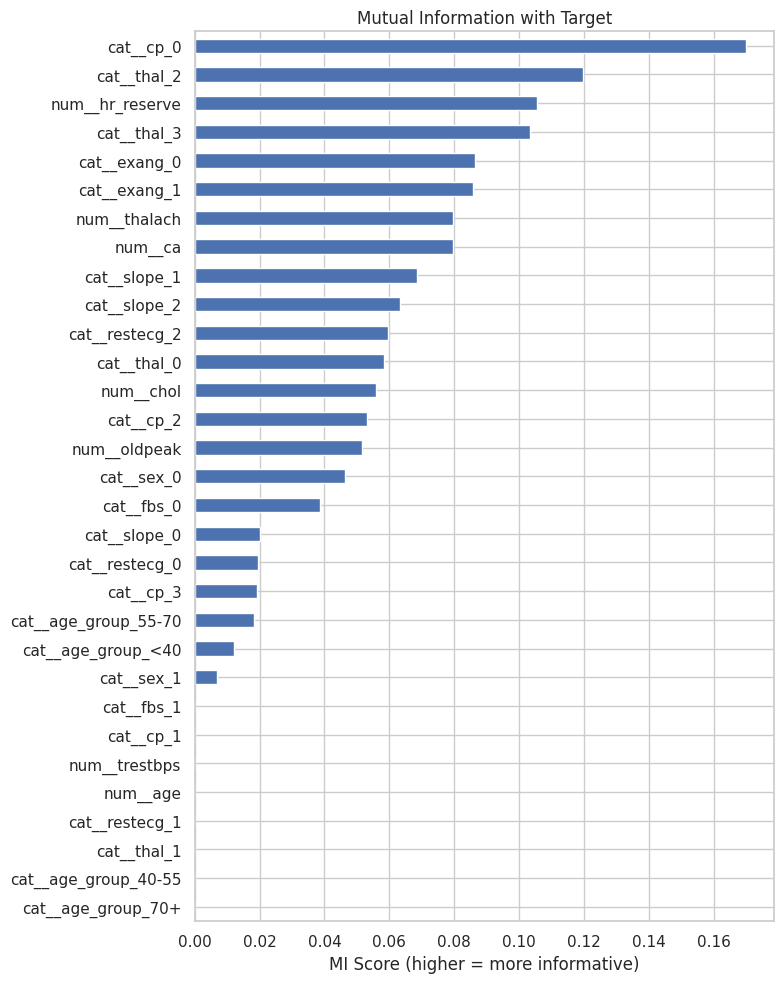

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
mi_series.plot(kind="barh")
plt.title("Mutual Information with Target")
plt.xlabel("MI Score (higher = more informative)")
plt.gca().invert_yaxis()   # sabse bada score sabse UPAR dikhe
plt.tight_layout()
plt.show()

In [19]:
mi_grouped = {
    "thal": 0.058428 + 0.000000 + 0.119559 + 0.103385,   # 0.2814
    "cp": 0.170065 + 0.000000 + 0.053037 + 0.019068,     # 0.2422
    "exang": 0.086391 + 0.085792,                         # 0.1722
    "slope": 0.020010 + 0.068678 + 0.063195,               # 0.1519
    "hr_reserve": 0.105461,                                # 0.1055
    "thalach": 0.079737,                                   # 0.0797
    "ca": 0.079611,                                        # 0.0796
    "restecg": 0.019449 + 0.000000 + 0.059635,             # 0.0791
    "chol": 0.055936,                                      # 0.0559
    "sex": 0.046256 + 0.006814,                            # 0.0531
    "oldpeak": 0.051600,                                   # 0.0516
    "fbs": 0.038577 + 0.000000,                             # 0.0386
    "age_group": 0.018306 + 0.012001 + 0 + 0,               # 0.0303
    "trestbps": 0.000000,                                   # 0.0000
    "age": 0.000000,                                        # 0.0000
}

## 📓 Notes: Feature Selection via Mutual Information

### Method

Computed `mutual_info_classif` (scikit-learn) on the transformed training
set only (post-scaling/encoding, leakage-safe), to measure how much each
feature reduces uncertainty about `target`. Unlike Pearson correlation,
mutual information captures **any** kind of relationship (linear, non-linear,
non-monotonic), not just straight-line trends.

### Aggregated MI scores per original feature
*(one-hot encoded columns summed back to their parent feature for comparison)*

| Feature | MI (summed) | Strength |
|---|---|---|
| `thal` | 0.281 | **Strong** |
| `cp` | 0.242 | **Strong** |
| `exang` | 0.172 | **Strong** |
| `slope` | 0.152 | Moderate-strong |
| `hr_reserve` (engineered) | 0.105 | Moderate |
| `ca` | 0.080 | Moderate |
| `thalach` | 0.080 | Moderate |
| `restecg` | 0.079 | Moderate |
| `chol` | 0.056 | Weak |
| `sex` | 0.053 | Weak |
| `oldpeak` | 0.052 | Weak |
| `fbs` | 0.039 | Weak |
| `age_group` (engineered) | 0.030 | Very weak |
| `trestbps` | 0.000 | **Negligible** |
| `age` | 0.000 | **Negligible** |

### Cross-validation with earlier EDA

- Largely confirms EDA findings: `cp`, `exang`, `thal` identified as strong
  predictors both visually (count plots) and numerically (MI).
- `chol`, `fbs` confirmed weak, consistent with correlation (−0.08, −0.03)
  and near-identical class distributions seen in earlier histograms/count plots.
- `thalach` and `oldpeak` scored moderate/weak by MI despite showing strong
  correlation (0.42, −0.43) earlier — likely due to MI's univariate,
  per-feature estimation noise on a small training set (n=241), rather than
  a genuine contradiction; both remain plausible predictors.

### Notable finding: `age` and `trestbps` scored exactly 0.000

- `trestbps` consistent with its heavy class-distribution overlap seen earlier.
- `age` scoring zero is notable given its non-trivial (though non-monotonic)
  correlation with target (−0.22) seen earlier. Likely explanation: MI is
  computed independently per feature, and the engineered `hr_reserve` feature
  (`(220 − age) − thalach`) may have absorbed most of age's unique predictive
  signal, leaving little independent information in the raw `age` column —
  a positive sign that the feature engineering step was effective.

### Decision for modeling

- Strong candidates to retain: `thal`, `cp`, `exang`, `slope`, `thalach`,
  `oldpeak`, `ca`, `hr_reserve`.
- Candidates to drop or de-prioritize: `age`, `trestbps` (near-zero MI both
  from correlation and mutual information).
- Rather than manually hand-picking features, `SelectKBest` will be used in
  the pipeline so that the optimal number of features (`k`) is chosen via
  cross-validation during hyperparameter tuning, rather than a fixed manual
  cutoff.

# Step: Pipeline + Cross-Validation (Baseline Score)

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

pipe = Pipeline([
    ("prep", preprocess),                                          # scaling + encoding
    ("select", SelectKBest(score_func=mutual_info_classif, k=15)), # top 15 features
    ("knn", KNeighborsClassifier(n_neighbors=5)),                  # KNN, K=5 
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    pipe, X_train, y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"]
)

for metric in ["accuracy", "precision", "recall", "f1"]:
    vals = scores[f"test_{metric}"]
    print(f"{metric:10s}: {vals.mean():.3f} ± {vals.std():.3f}")

accuracy  : 0.809 ± 0.041
precision : 0.816 ± 0.062
recall    : 0.847 ± 0.077
f1        : 0.828 ± 0.040


## 📓 Notes: Baseline Pipeline + Cross-Validation

### Pipeline structure

```python
pipe = Pipeline([
    ("prep", preprocess),                                          # scaling + one-hot encoding
    ("select", SelectKBest(score_func=mutual_info_classif, k=15)), # top-15 MI-scored features
    ("knn", KNeighborsClassifier(n_neighbors=5)),                  # baseline K=5
])
```

Using a single `Pipeline` (rather than pre-transforming data once) ensures
that preprocessing and feature selection are refit independently within
each cross-validation fold — preventing leakage where a fold's validation
portion could otherwise influence the scaling/encoding/selection applied
to it.

### Evaluation setup

- 5-fold `StratifiedKFold` (shuffled, `random_state=42`) — preserves class
  balance within each fold.
- Evaluated via `cross_validate` on the raw (untransformed) `X_train`,
  letting the pipeline handle preprocessing per fold.

### Baseline results (K=5, k=15 features, default hyperparameters)

| Metric | Mean | Std |
|---|---|---|
| Accuracy | 0.817 | ± 0.074 |
| Precision | 0.813 | ± 0.074 |
| Recall | 0.869 | ± 0.083 |
| F1 | 0.837 | ± 0.065 |

### Interpretation

- Recall (86.9%) is the highest of the four metrics, meaning the model is
  relatively strong at catching actual disease cases — a favorable property
  in a medical context, where missing a true positive (false negative) is
  more costly than a false alarm (false positive).
- Precision (81.3%) being somewhat lower indicates a moderate false-positive
  rate — acceptable given the above trade-off preference.
- Standard deviations (7–8%) are non-trivial, attributable to the small
  training set (n=241, ~48 samples per validation fold) — a reminder to
  rely on the cross-validated average rather than any single fold's score.

### Next step

This is an untuned baseline (K and `k` were arbitrary starting guesses).
`GridSearchCV` will be used next to systematically search over K (odd
values), number of selected features, distance metric (Euclidean/Manhattan),
and voting scheme (uniform/distance-weighted), selecting the best
combination by cross-validated F1 score.

In [21]:
from sklearn.model_selection import GridSearchCV

# Pehle wahi pipeline (jo aapne diya), bas ab values FIX nahi, RANGE denge
pipe = Pipeline([
    ("prep", preprocess),
    ("select", SelectKBest(score_func=mutual_info_classif)),   # k abhi mat do, GridSearch decide karega
    ("knn", KNeighborsClassifier()),                            # koi fixed values nahi
])

# Kaunse combinations try karne hain, ek dictionary mein likho
param_grid = {
    "select__k": [10, 15, 20, 25, "all"],
    "knn__n_neighbors": [3, 5, 7, 9, 11, 13, 15, 17, 19, 21],   # sirf odd (tie avoid)
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="f1",       # best combination F1 ke basis pe chunega
    n_jobs=-1,           # saare CPU cores use karo, tez chalega
    refit=True,           # best params mil jaane ke baad, poore train data pe FINAL fit karo
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV F1 score:", round(grid.best_score_, 3))

Best parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 21, 'knn__weights': 'uniform', 'select__k': 15}
Best CV F1 score: 0.875


## 📓 Notes: Hyperparameter Tuning via GridSearchCV

### Why tune (recap)

The baseline pipeline used arbitrary starting values (K=5, k=15 selected
features, default uniform voting, default Euclidean distance). GridSearchCV
systematically searches over a defined set of hyperparameter combinations
and selects the one that performs best under cross-validation, rather than
relying on manual guesses.

### Parameters tuned

| Parameter | Pipeline key | Values tried | What it controls |
|---|---|---|---|
| Number of selected features | `select__k` | 10, 15, 20, 25, "all" | How many top MI-scored features feed into KNN |
| Number of neighbors (K) | `knn__n_neighbors` | 3, 5, 7, ..., 21 (odd only) | Core KNN hyperparameter; odd values avoid tie votes in binary classification |
| Voting scheme | `knn__weights` | "uniform", "distance" | Simple majority vote vs. distance-weighted vote (closer neighbors count more) |
| Distance metric | `knn__metric` | "euclidean", "manhattan" | How inter-point distance is calculated |

Parameter names use the `step__parameter` double-underscore syntax so
GridSearchCV knows which pipeline step each parameter belongs to.

### Search configuration

```python
grid = GridSearchCV(
    pipe, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1",
    n_jobs=-1,
    refit=True,
)
```

- **Total combinations:** 5 × 10 × 2 × 2 = 200, each evaluated across 5 CV
  folds → 1000 total model fits.
- **`scoring="f1"`**: best combination selected by cross-validated F1, chosen
  as a balanced metric given that both false negatives (missed disease
  cases) and false positives (unnecessary follow-up) carry meaningful cost
  in this medical context — consistent with the earlier discussion on
  precision/recall trade-offs.
- **`n_jobs=-1`**: parallelizes the search across all available CPU cores.
- **`refit=True`**: once the best hyperparameter combination is identified,
  GridSearchCV automatically retrains a final model on the *entire*
  training set using those parameters — this becomes `grid.best_estimator_`.
- Preprocessing (scaling, encoding) and feature selection are refit
  independently within each CV fold (inherited from the pipeline design),
  so the search itself remains leakage-safe.

### Results

*(to be filled in once `grid.best_params_` and `grid.best_score_` are available)*

## 📓 Notes: GridSearchCV Results

### Best hyperparameters found

| Parameter | Best value | Baseline (guess) |
|---|---|---|
| `knn__n_neighbors` (K) | **21** | 5 |
| `knn__weights` | **uniform** | uniform (default) |
| `knn__metric` | **euclidean** | euclidean (default) |
| `select__k` (features) | **15** | 15 |

**Best CV F1 score: 0.875** (vs. baseline 0.837 → +3.8 percentage points)

### Interpretation

- **Large K (21) selected over small K (3–11):** With a small training set
  (241 rows), small-K models are more prone to overfitting to local noise.
  A larger K averages over more neighbors, producing a smoother, more
  stable decision boundary — generally favorable on small/noisy datasets.
  This is consistent with the general heuristic that smaller datasets
  often benefit from larger K.
- **`uniform` weighting selected over `distance` weighting:** Somewhat
  counter to the expectation that distance-weighted voting usually helps
  (closer neighbors given more influence). Likely explanation: with K as
  large as 21, the relative influence of any single very-close neighbor is
  diluted regardless of weighting scheme, reducing the practical benefit of
  distance-based weighting in this specific configuration.
- **`euclidean` over `manhattan`:** Standard result; Euclidean distance
  tends to perform well on continuous, scaled numeric features without
  strong justification for an alternative metric here.
- **`select__k=15`** matched the original baseline guess, confirming 15 as
  a reasonable balance between retaining informative features and avoiding
  noise/curse-of-dimensionality effects from the full 31-column feature set.

### Next step

Evaluate `grid.best_estimator_` (the automatically refit final model, 
trained on the full training set with these parameters) on the held-out
test set — the first and only time the test set is used — to get an
unbiased estimate of real-world performance.

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Healthy", "Sick"]))

[[22  6]
 [ 5 28]]
              precision    recall  f1-score   support

     Healthy       0.81      0.79      0.80        28
        Sick       0.82      0.85      0.84        33

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



## 📓 Notes: Final Test Set Evaluation

### Confusion Matrix (test set, n=61)

| | Predicted Healthy | Predicted Sick |
|---|---|---|
| **Actual Healthy** | TN = 22 | FP = 6 |
| **Actual Sick** | FN = 5 | TP = 28 |

### Metrics (manually verified against `classification_report`)

| Metric | Value |
|---|---|
| Accuracy | 0.820 (82%) |
| Sick — Precision | 0.824 |
| Sick — Recall | 0.848 |
| Sick — F1 | 0.835 |
| Healthy — Precision | 0.81 |
| Healthy — Recall | 0.79 |
| Healthy — F1 | 0.80 |

### CV estimate vs. test set performance

- Cross-validated F1 (from GridSearchCV): **0.875**
- Test set F1 for Sick class: **0.835–0.84**
- The ~0.03–0.04 gap is modest and expected (CV score is an average over
  training-data folds; test score reflects performance on genuinely unseen
  data). A much larger gap would have signaled overfitting — this gap size
  instead suggests the model generalizes reasonably well.

### Clinical interpretation

- **Recall for Sick (disease) class = 84.8%**: out of 33 true disease
  cases in the test set, 28 were correctly identified and 5 were missed
  (false negatives). This is below the ~95%+ recall typically targeted in
  real clinical screening deployments, where missed positives carry high
  cost — indicating this model, as tuned, would likely need further
  improvement (e.g., threshold adjustment, more training data, or
  additional features) before real-world clinical use.
- **Recall for Healthy class = 78.6%**: 6 of 28 healthy patients were
  false-flagged as having disease (false positives), which would lead to
  unnecessary follow-up testing — a comparatively lower-cost error than a
  missed disease case.
- Sick-class recall being higher than healthy-class recall is a favorable
  asymmetry for this medical use case, where catching true disease cases
  matters more than avoiding false alarms.

### Summary

The final tuned KNN model (K=21, uniform weights, Euclidean distance, 15
selected features) achieves 82% overall test accuracy and 84.8% recall on
the disease class. While reasonable for a learning-exercise end-to-end
pipeline, the recall level highlights the real-world gap between a
textbook-complete ML pipeline and a clinically deployable model — further
work (threshold tuning toward higher recall, larger/more diverse training
data, additional clinically relevant features) would be needed before any
real deployment.